In [8]:
import pandas as pd
import os

#### Merging 12 months of sales data into a single file

In [15]:
df = pd.read_csv("./SalesAnalysis/Sales_Data/Sales_April_2019.csv")
files = [file for file in os.listdir("./SalesAnalysis/Sales_Data") if file.endswith(".csv")]
all_month_data = pd.DataFrame()
for file in files:
    df = pd.read_csv("./SalesAnalysis/Sales_Data/" + file)
    all_month_data = pd.concat([all_month_data, df])
all_month_data.to_csv("./SalesAnalysis/Sales_Data/all_month_data.csv", index=False)

In [17]:
all_data = pd.read_csv("./SalesAnalysis/Sales_Data/all_month_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",NaN
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",NaN
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",NaN
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",NaN
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",NaN


### Clean up the data!

#### Drop rows of NAN

In [25]:
nan_df = all_data[all_data.isna().any(axis=1)]
all_data = all_data.dropna(how='all')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,08
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,08
97994,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,08
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,08
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,08


#### Find 'Or' and delete it

In [31]:
all_data = all_data[all_data['Order Date'].str[0:2] != 'Or']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,08
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,08
97994,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,08
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,08
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,08


##### Convert columns to the correct type

In [35]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered']) # Make int
all_data['Price Each'] = pd.to_numeric(all_data['Price Each']) # Make float

### Augment data with aditional columns

### Task 2: Add Month Column

In [36]:
all_data['Month'] = all_data['Order Date'].str[0:2]
all_data['Month'] = all_data['Month'].astype('int32')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8


#### Task 3: Add a sales column

In [37]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month,Sales
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8,23.98
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8,99.99
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8,700.00
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8,7.68
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8,7.68


#### Task 4: Add a city column

In [63]:
# Let's use the .apply() method
def get_city(address):
    return address.split(',')[1]
def get_state(address):
    return address.split(',')[2].split(' ')[1]
all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")
all_data.head()
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month,Sales,City
97992,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101",0.0,8,23.98,Seattle (WA)
97993,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001",1.0,8,99.99,Dallas (TX)
97994,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035",2.0,8,700.00,Portland (OR)
97995,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001",3.0,8,7.68,Los Angeles (CA)
97996,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001",4.0,8,7.68,New York City (NY)


#### Question 1 What was the best month for sales? How much was earned that month?

In [64]:
results  = all_data.groupby('Month').sum()

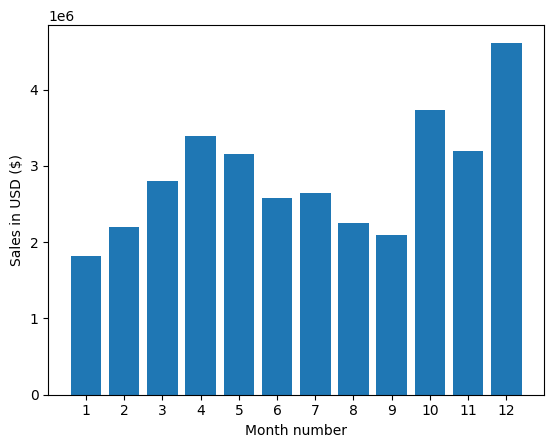

In [65]:
import matplotlib.pyplot as plt

months = range(1,13)

plt.bar(months, results['Sales'])
plt.xticks(months)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month number')
plt.show()

### What city had the best sales

In [69]:
cresults = all_data.groupby('City').sum()
cresults

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Unnamed: 0,Month,Sales
City,,,,,,,,,
Atlanta (GA),2366852366992367032367142367172367192367442367...,Apple Airpods HeadphonesAA Batteries (4-pack)B...,16602,2779908.20,08/23/19 19:2908/20/19 21:0708/08/19 06:0908/3...,"238 Highland St, Atlanta, GA 30301763 Hill St,...",122928154.0,104794,2795498.58
Austin (TX),2367052367102367492367522367732367742367952368...,AA Batteries (4-pack)Macbook Pro LaptopAAA Bat...,11153,1809873.61,08/11/19 22:2108/04/19 02:4608/30/19 20:1308/2...,"27 North St, Austin, TX 73301654 Chestnut St, ...",82709457.0,69829,1819581.75
Boston (MA),2366812366912367122367262367352367392367412367...,AA Batteries (4-pack)USB-C Charging CableAA Ba...,22528,3637409.77,08/26/19 20:5208/23/19 07:3408/30/19 07:1408/2...,"295 1st St, Boston, MA 02215916 Meadow St, Bos...",165758780.0,141112,3661642.01
Dallas (TX),2366712366832366862366982367022367112367202367...,Bose SoundSport Headphones27in FHD MonitorAAA ...,16730,2752627.82,08/15/19 15:1108/31/19 15:4708/15/19 19:1308/0...,"492 Ridge St, Dallas, TX 75001196 West St, Dal...",124308328.0,104620,2767975.40
Los Angeles (CA),2366732366762366792366882367002367072367362367...,AA Batteries (4-pack)34in Ultrawide MonitorMac...,33289,5421435.23,08/29/19 20:5908/04/19 19:5208/07/19 15:4308/0...,"631 2nd St, Los Angeles, CA 90001470 Cherry St...",247743297.0,208325,5452570.80
New York City (NY),2366742366842366872366942366962367232367272367...,AA Batteries (4-pack)Lightning Charging CableU...,27932,4635370.83,08/15/19 19:5308/09/19 16:5008/23/19 12:5408/1...,"736 14th St, New York City, NY 10001669 12th S...",208439450.0,175741,4664317.43
Portland (ME),2367282367512368152368662368912369002369662372...,ThinkPad Laptop27in 4K Gaming Monitor27in FHD ...,2750,447189.25,08/10/19 11:2108/03/19 09:1808/28/19 17:5508/1...,"526 North St, Portland, ME 04101534 Washington...",20641344.0,17144,449758.27
Portland (OR),2366722366822366932367152367682367722368422368...,iPhoneAA Batteries (4-pack)27in 4K Gaming Moni...,11303,1860558.22,08/06/19 14:4008/19/19 12:4008/12/19 21:5708/2...,"149 7th St, Portland, OR 97035118 Johnson St, ...",83402354.0,70621,1870732.34
San Francisco (CA),2366752366772366782366802366892366902366922366...,Wired Headphones20in MonitorWired HeadphonesLG...,50239,8211461.74,08/02/19 23:5408/13/19 07:1608/25/19 20:1108/0...,"470 Hill St, San Francisco, CA 94016918 6th St...",372569180.0,315520,8262203.91


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (12,).

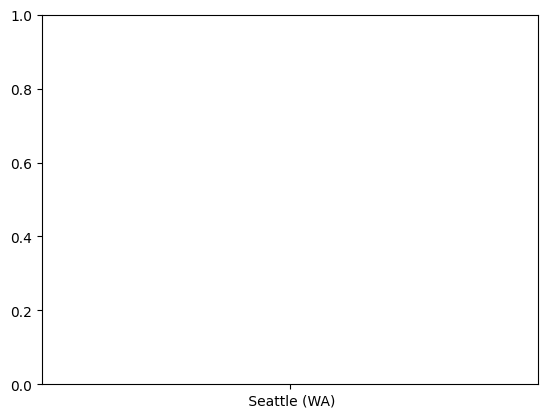

In [71]:
cities = all_data['City'].unique()

plt.bar(cities, results['Sales'])
plt.xticks(cities, rotation='vertical', size=8)
plt.ylabel('Sales in USD ($)')
plt.ylabel('Sales in USD ($)')
plt.xlabel('City name')
plt.show()